In [57]:
# 1] import all necessary libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, ops
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [58]:
# 2] Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize and reshape
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (-1, 784))
x_test = np.reshape(x_test, (-1, 784))

In [59]:
input_dim = 784
latent_dim = 2

In [60]:
# 3] Encoder
inputs = layers.Input(shape =(input_dim,))
h = layers.Dense(256, activation="relu")(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)

In [61]:
# 4] Sampling function
def sampling(args):
  z_mean, z_log_var = args
  epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0],latent_dim))
  return z_mean + tf.exp(0.5 * z_log_var)* epsilon

In [62]:
z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

In [63]:
# 5] Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
h_decoded = layers.Dense(256, activation="relu")(latent_inputs)
outputs = layers.Dense(input_dim, activation="sigmoid")(h_decoded)
decoder = Model(latent_inputs, outputs, name="decoder")

In [64]:
# 6] VAE Model
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name="vae")

In [65]:
# 7] Loss Function
class VAELossLayer(Layer):
    def call(self, inputs):
        inputs, outputs, z_mean, z_log_var = inputs
        reconstruction_loss = ops.binary_crossentropy(inputs, outputs) * input_dim
        kl_loss = -0.5 * ops.mean(1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
        self.add_loss(reconstruction_loss + kl_loss)
        return outputs

In [66]:
outputs = VAELossLayer()([inputs, outputs, z_mean, z_log_var])
vae = Model(inputs, outputs)

In [67]:
# 8] Compile
vae.compile(optimizer='adam')

In [68]:
#  9] Train Model
vae.fit(x_train, epochs=10, batch_size=128, validation_data=(x_test,
None))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 20229806.0000 - val_loss: 17569420.0000
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 17148688.0000 - val_loss: 16730613.0000
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 16665017.0000 - val_loss: 16442265.0000
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 16390519.0000 - val_loss: 16212799.0000
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 16173246.0000 - val_loss: 16067717.0000
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 16014974.0000 - val_loss: 15937413.0000
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 15884416.0000 - val_loss: 15830072.0000
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 15773521.0000 - val_loss: 15724631.0000
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 15662813.0000 - val_loss: 15627431.0000
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 15569966.0000 - val_loss: 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


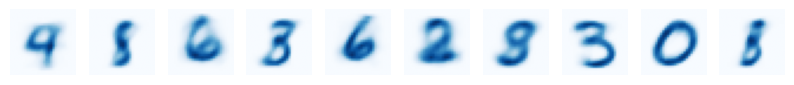

In [71]:
# 9] Generate Images
# Sample random latent points
z_sample = np.random.normal(size=(10, latent_dim))
generated_images = decoder.predict(z_sample)
# Plot generated images
plt.figure(figsize=(10, 2))
for i in range(10):
  plt.subplot(1, 10, i+1)
  plt.imshow(generated_images[i].reshape(28, 28), cmap='Blues')
  plt.axis('off')
plt.show()